[!!!] Usar unrotate = True destruye la información sobre la posición del crop en la instancia de AnnotatedPage. Además, reduce la calidad de las imágenes por usar interpolación bicúbica, y esta misma interpolación introduce artefactos visuales en los bordes de la imagen. Úsese solamente en caso de revisión manual de las imágenes, y NO para el código de generación del dataset.
También invalida la forma en la que se generan los párrafos, la transcripción y los starting_indices.
-- -- -- -- -- -- -- -- ANOTACIÓN 0 -- -- PÁRRAFO 0


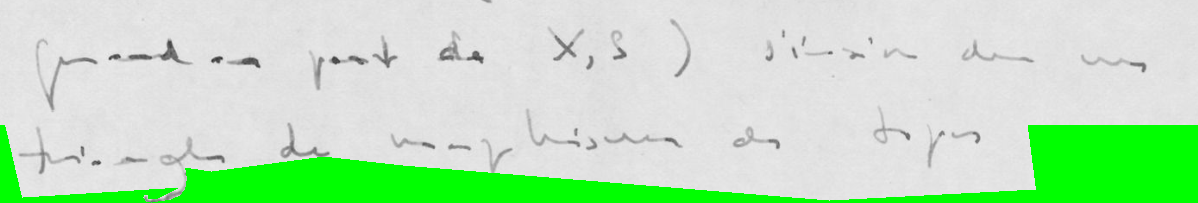

<IPython.core.display.Latex object>

-- -- -- -- -- -- -- -- ANOTACIÓN 0 -- -- PÁRRAFO 1


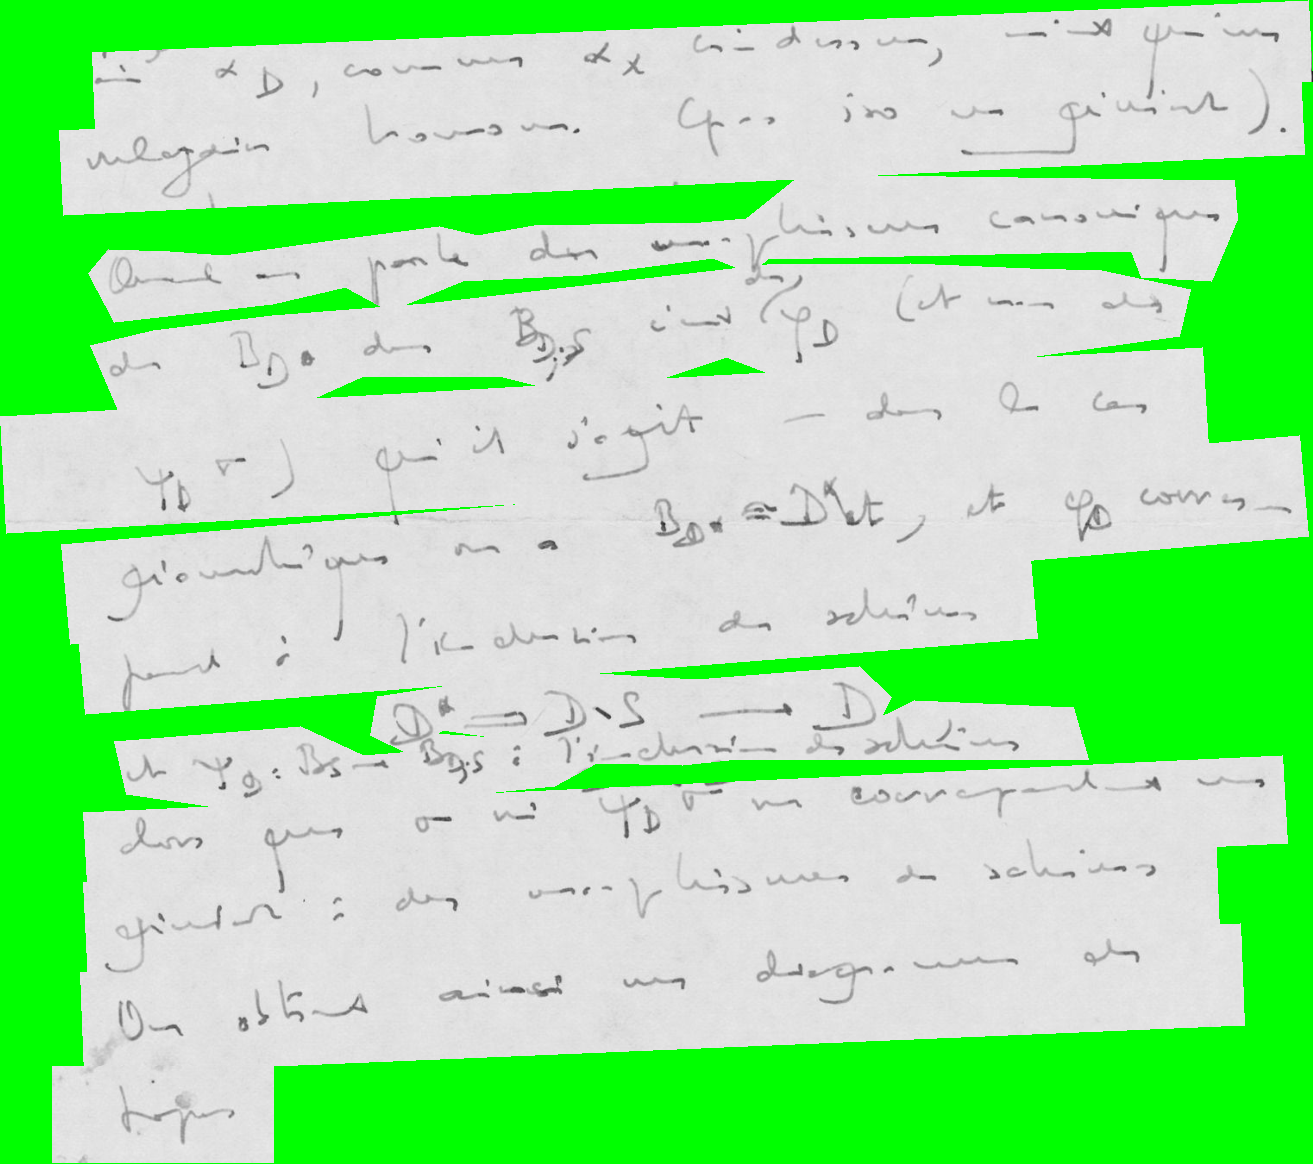

<IPython.core.display.Latex object>

KeyboardInterrupt: Interrupted by user

In [2]:
from cropgen.shared.PathBundle import PathBundle
from cropgen.external_interfaces.LabelStudioInterface import LabelStudioInterface
from IPython.display import clear_output, Latex
from cropgen.processing.AnnotatedPage import AnnotatedPage
from PIL import Image

paths = PathBundle()

lsi = LabelStudioInterface(paths)

#cajas revisadas hasta la 341.
max_revised = 126 #poner aquí la página por la que se está revisando.

INVERSE_ORDER = False

tasks = [task for task in sorted(lsi.simplified_tasks, key = lambda task : task["id"]) if task["id"] > max_revised]

if INVERSE_ORDER:
    tasks = tasks[::-1]


AnnotatedPage.min_nodes_for_big_box_removal = 500 #como usar unrotate = True nos destruye la información de adyacencias, lo mejor es no eliminarlos.

for task in tasks:
    task_id = task["id"]

    img = Image.open(paths.get_image_path_from_task(task))


    for (k,ann) in enumerate(task["annotations"]):

        #Primero con unrotate = True (comprobación de los recortes individuales)
        Ann_rot = AnnotatedPage(ann, img, unrotate = True, usernames_labelstudio= lsi.usernames)
        # print(f"-- -- Llevas un {len([x for x in LS.raw_tasks if x["id"] <= task_id]) / len(LS_export_data) * 100:.2f}%")
        # print(f"-- -- TAREA {task_id} -- ANOTACIÓN {k} --")
        # print(f"-- -- --       Completada por: {Ann_rot.completer:<25}")
        # print(f"-- -- -- Último actualización: {Ann_rot.updater:<25} con fecha de {Ann_rot.last_update_time}")
        #
        #
        # for (par_index, paragraph) in enumerate(Ann_rot.paragraphs):
        #     print(f"-- -- -- -- -- -- -- -- ANOTACIÓN {k} -- -- PÁRRAFO {par_index}")
        #     for (box_index, box) in enumerate(paragraph.image_boxes):
        #         print(f"({task_id}) - Párrafo {par_index+1}/{len(Ann_rot.paragraphs)}, caja {box_index+1}/{len(paragraph.image_boxes)}")
        #         display(Ann_rot.generate_collage([box.id], background_color = (255, 128, 255)))
        #         display(Latex(box.fragment.text))
        #         print("\n")

        #Ahora sin unrotate, comprobación de los párrafos:
        Ann_unrot = AnnotatedPage(ann, img, unrotate = False, usernames_labelstudio= lsi.usernames)

        for (par_index, paragraph) in enumerate(Ann_unrot.paragraphs):
            print(f"-- -- -- -- -- -- -- -- ANOTACIÓN {k} -- -- PÁRRAFO {par_index}")
            display(Ann_unrot.generate_collage([b.id for b in paragraph.image_boxes], background_color = (0, 255, 0)))
            display(Latex(paragraph.transcription()))





        a = input("Continuamos? (vacío para continuar)")
        if a.lower() != "":
            raise KeyboardInterrupt("Se ha parado el proceso")

        clear_output(wait = True)

In [ ]:
par = Ann_unrot.paragraphs[-1]
ppolygons = [b.polygon for b in par.image_boxes]

In [ ]:
par.union_polygon()

In [ ]:
Ann_rot.cluster_reading_order(par.image_boxes_ids)[0]

In [ ]:
Ann_rot.paragraphs[1].subgraph